In [10]:
import os
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import pingouin as pg
import seaborn as sns
from dotenv import load_dotenv

from multipred.analyses import (decoding_attended_modalities_stats,
                                decoding_crossmodal_stats,
                                test_decoding_above_chance)
from multipred.plotting import (barplot_morey, plot_crossmodal,
                                plot_decoding_modalities,
                                plot_decoding_modalities_attention,
                                plot_decoding_pred)

In [11]:
load_dotenv("../../.env")
PROJECT_PATH = os.getenv("PROJECT_PATH")
DATA_PATH = f"{PROJECT_PATH}/data/derivatives/decoding_data/"
ROI = "EVC"

## Comparing decoding across modalities

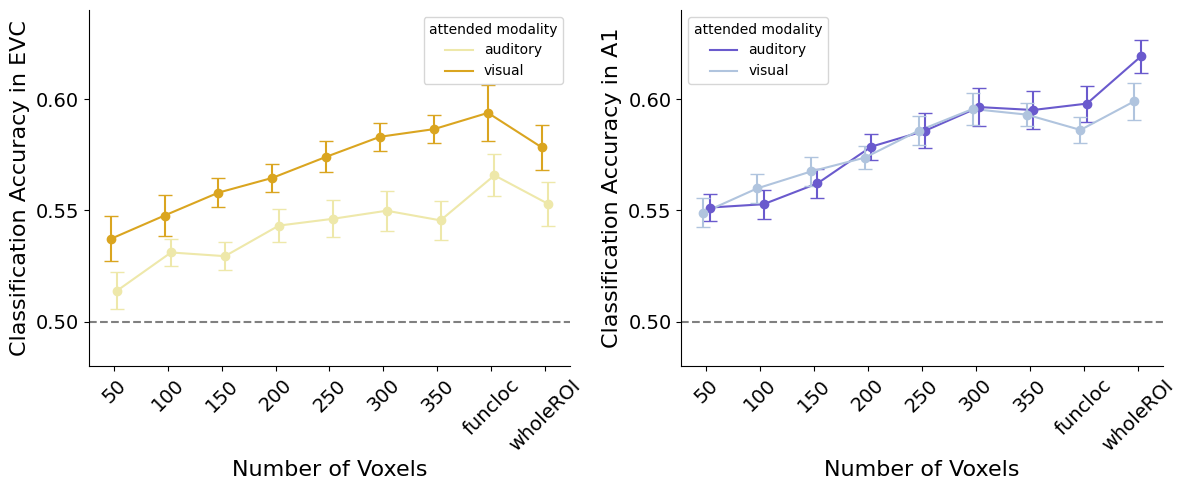

In [12]:
n_voxels_list = [
    "50",
    "100",
    "150",
    "200",
    "250",
    "300",
    "350",
    "funcloc",
    "wholeROI",
]
df_allROIs = plot_decoding_modalities_attention(DATA_PATH, n_voxels_list, error_type="wsSE", save_fig=False)
df_decoding_abovechance = test_decoding_above_chance(df_allROIs, n_voxels_list) # create a dataframe with results of a binomial test
df_decoding_modalities_xattention = decoding_attended_modalities_stats(# create a dataframe with results of a t-test for decoding attended modalities
    df_allROIs, n_voxels_list
)  

# df_decoding_abovechance.to_csv("tables/decoding_abovechance.csv", index=False)
# df_decoding_modalities_xattention.to_csv("tables/decoding_modalities_attention.csv", index=False)

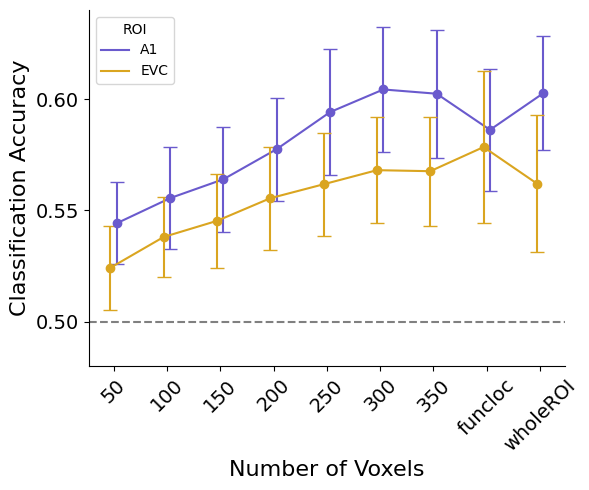

In [4]:
n_voxels_list = [
    "50",
    "100",
    "150",
    "200",
    "250",
    "300",
    "350",
    "funcloc",
    "wholeROI",
]

df_all, df_stats = plot_decoding_modalities(DATA_PATH, n_voxels_list, save_fig=False)

# # Show the summary of decoding results
# print("\nSummary of decoding accuracy statistics:")
# print(df_stats.round(4).to_string(index=False))

## Analyze Attention * Prediction for specific ROI size

In [5]:
ROI = "EVC"
n_voxels = "wholeROI"
df = pd.read_csv(f"{DATA_PATH}/{ROI}_{n_voxels}/balanced_group_data.csv")

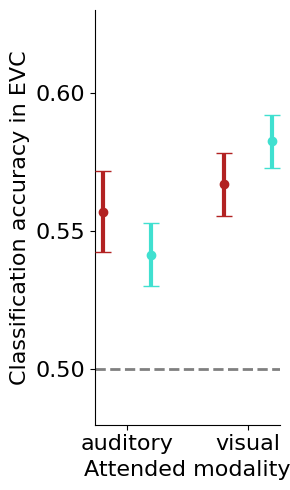

In [8]:
y = "correct"
x = "modality"
hue = "v_pred"
id = "subj"
savefig = False
errorbar_style={"capsize": 6, "elinewidth": 3, "markersize": 6}

dat = df.copy().groupby([id, x, hue], as_index=False)[y].mean()
fig, ax = plt.subplots(figsize=(3, 5))
barplot_morey(dat, x, y, hue, "visual expected", ["firebrick", "turquoise"], ["lightcoral", "powderblue"], False, False, False, ax, legend=False, errorbar_style=errorbar_style, fontsize=16)
sns.despine()
plt.xticks([0, 1], ["auditory", "visual"])
plt.ylabel(f"Classification accuracy in {ROI}")
plt.xlabel("Attended modality")
plt.ylim(0.48, 0.63)
plt.yticks([0.5, 0.55, 0.6])
plt.axhline(0.5, color="grey", linestyle="--", linewidth=2)
plt.tight_layout()
if savefig:
    plt.savefig(f"figures/MVPA/attention_pred_{ROI}.svg", dpi=300)
plt.show()

In [9]:
df.groupby(["v_pred"])[y].mean()

v_pred
0    0.561987
1    0.562046
Name: correct, dtype: float64

In [10]:
pg.rm_anova(dv=y, within=[x, hue], subject=id, data=dat.copy())

c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\pingouin\distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\pingouin\distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,modality,1.613959e-02,1,24,1.613959e-02,3.725103,0.065501,0.065501,2.005266e-02,1.0
1,v_pred,8.506944e-08,1,24,8.506944e-08,0.000022,0.996300,0.996300,1.078575e-07,1.0
2,modality * v_pred,6.071007e-03,1,24,6.071007e-03,2.557319,0.122868,0.122868,7.638489e-03,1.0


In [11]:
pg.pairwise_tests(dv=y, within=[hue], subject=id, data=dat[dat["modality"]=="visual"], alternative="less", effsize="cohen")

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,cohen
0,v_pred,0,1,True,True,-1.251142,24.0,less,0.111471,0.847,-0.169413


In [12]:
pg.pairwise_tests(dv=y, within=[hue], subject=id, data=dat[dat["modality"]=="auditory"], alternative="greater", effsize="cohen")

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,cohen
0,v_pred,0,1,True,True,0.837512,24.0,greater,0.205284,0.579,0.174591


## Multimodal analyses

### Check interaction across ROI sizes

#### Visual attended

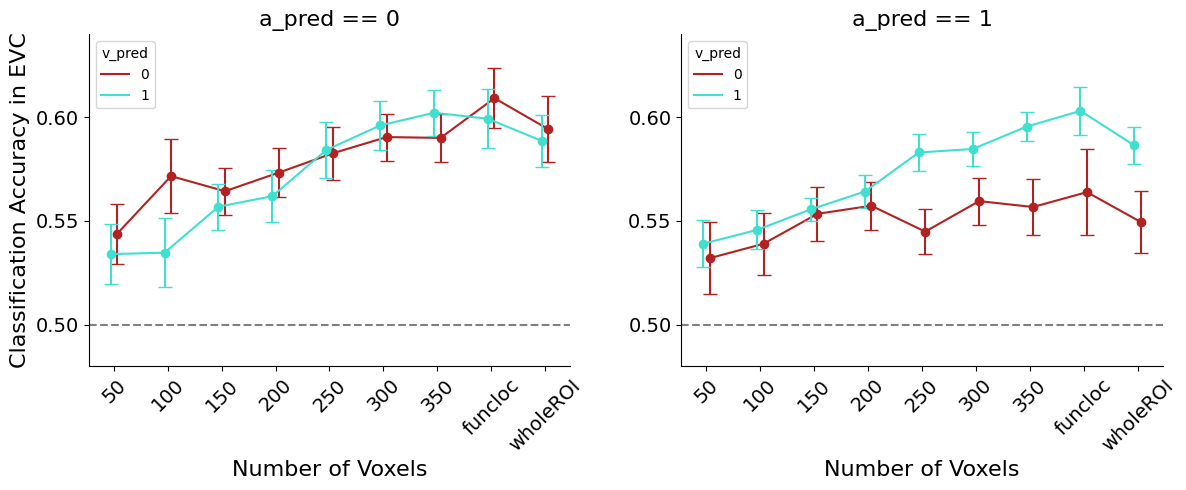

In [14]:
n_voxels_list = [
    "50",
    "100",
    "150",
    "200",
    "250",
    "300",
    "350",
    "funcloc",
    "wholeROI",
]
ROI = "EVC"
hue = "v_pred"
col = "a_pred"
attended_modality = "visual"
palette = ["firebrick", "turquoise"]
df_attended = plot_decoding_pred(DATA_PATH, ROI, n_voxels_list, hue, col, palette, attended_modality, error_type="wsSE", save_fig=False)


Compute stats for each ROI size, and save them

In [15]:
factors = ("a_pred", "v_pred")
alternative = "less" # sharpening specific hypothesis

with warnings.catch_warnings(): # hiding some pingouin warnings
    warnings.simplefilter("ignore", category=FutureWarning)
    anova_df, ttest_df = decoding_crossmodal_stats(df_attended, within_factors=factors, alternative=alternative)

# Customize dataframe to create tables
roi_order = ["50", "100", "150", "200", "250", "300", "350", "funcloc", "wholeROI"]

# Reorder column and sort for anova_df
anova_df["n_voxels_label"] = pd.Categorical(anova_df["n_voxels_label"], categories=roi_order, ordered=True)
anova_df = anova_df.sort_values("n_voxels_label")

# Move n_voxels_label to first column
cols = ["n_voxels_label"] + [col for col in anova_df.columns if col != "n_voxels_label"]
anova_df = anova_df[cols]

# Same for ttest_df
ttest_df["n_voxels_label"] = pd.Categorical(ttest_df["n_voxels_label"], categories=roi_order, ordered=True)
ttest_df = ttest_df.sort_values("n_voxels_label")

cols = ["n_voxels_label"] + [col for col in ttest_df.columns if col != "n_voxels_label"]
ttest_df = ttest_df[cols]

# Save ANOVA and t-test tables. Will be imported in R to generate latex tables
anova_df.reset_index().to_csv("tables/v_decoding_attended_anova.csv", index=False)
ttest_df.reset_index().to_csv("tables/v_decoding_attended_ttests.csv", index=False)

#### Auditory attended

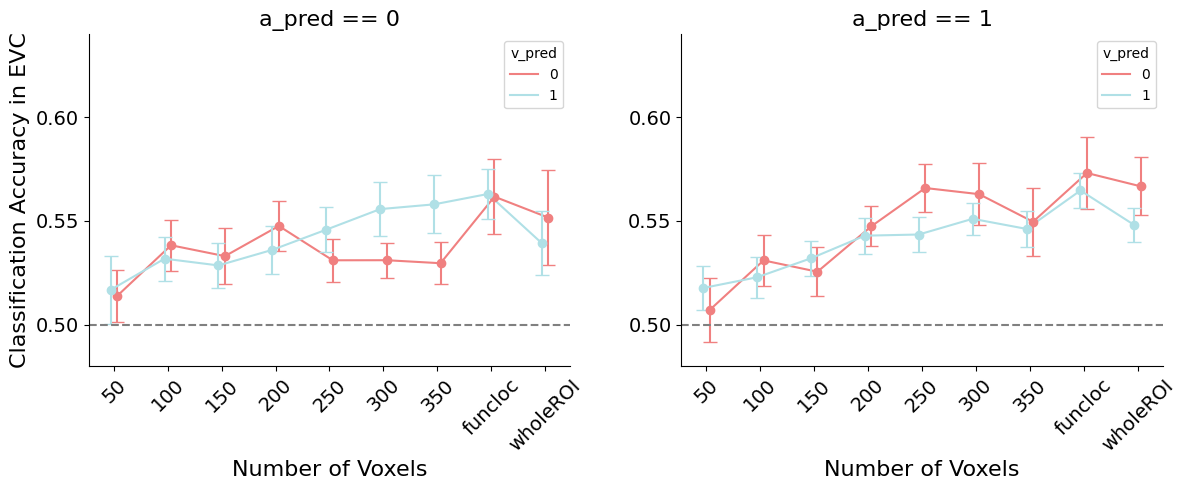

In [17]:
n_voxels_list = [
    "50",
    "100",
    "150",
    "200",
    "250",
    "300",
    "350",
    "funcloc",
    "wholeROI",
]

ROI = "EVC"
hue = "v_pred"
col = "a_pred"
attended_modality = "auditory"
palette = ["lightcoral", "powderblue"]
df_unattended = plot_decoding_pred(DATA_PATH, ROI, n_voxels_list, hue, col, palette, attended_modality, error_type="wsSE", save_fig=False)

Compute stats for each ROI size, and save them

In [18]:
factors = ("a_pred", "v_pred")
alternative = "greater" # dampening specific hypothesis

with warnings.catch_warnings(): # hiding some pingouin warnings
    warnings.simplefilter("ignore", category=FutureWarning)
    anova_df, ttest_df = decoding_crossmodal_stats(df_unattended, within_factors=factors, alternative=alternative)

# Customize dataframe to create tables
roi_order = ["50", "100", "150", "200", "250", "300", "350", "funcloc", "wholeROI"]

# Reorder column and sort for anova_df
anova_df["n_voxels_label"] = pd.Categorical(anova_df["n_voxels_label"], categories=roi_order, ordered=True)
anova_df = anova_df.sort_values("n_voxels_label")

# Move n_voxels_label to first column
cols = ["n_voxels_label"] + [col for col in anova_df.columns if col != "n_voxels_label"]
anova_df = anova_df[cols]

# Same for ttest_df
ttest_df["n_voxels_label"] = pd.Categorical(ttest_df["n_voxels_label"], categories=roi_order, ordered=True)
ttest_df = ttest_df.sort_values("n_voxels_label")

cols = ["n_voxels_label"] + [col for col in ttest_df.columns if col != "n_voxels_label"]
ttest_df = ttest_df[cols]

# Save ANOVA and t-test tables. Will be imported in R to generate latex tables
anova_df.reset_index().to_csv("tables/v_decoding_unattended_anova.csv", index=False)
ttest_df.reset_index().to_csv("tables/v_decoding_unattended_ttests.csv", index=False)

### Check cross-modal effect for a specific ROI size

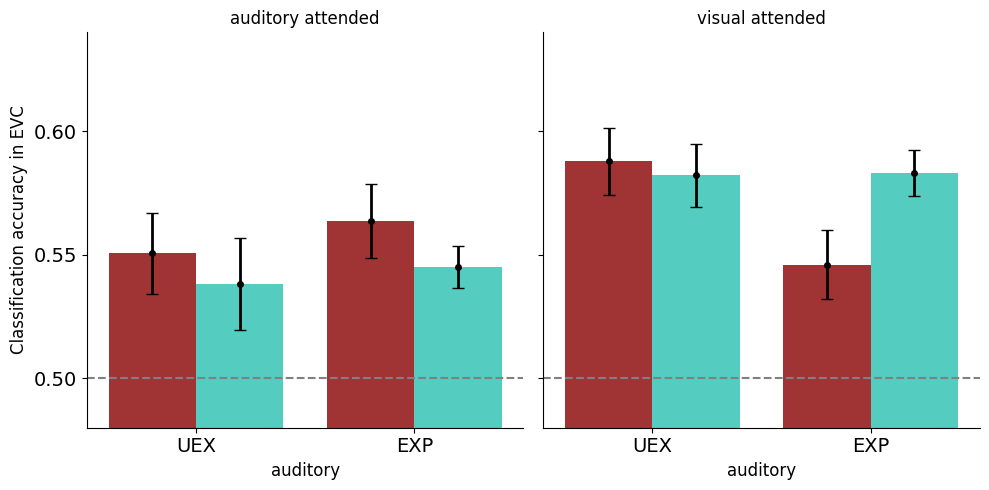

In [ ]:
y = "correct"
x = "a_pred"
hue = "v_pred"
id = "subj"
ROI = "EVC"
save_fig = False
ylim = (0.48, 0.64)
yticks = [0.5, 0.55, 0.6]

ROI = "EVC"
n_voxels = "wholeROI"
df = pd.read_csv(f"{DATA_PATH}/{ROI}_{n_voxels}/balanced_group_data.csv")
df_grouped = df.groupby(["subj", "modality", "a_pred", "v_pred"], as_index=False)[y].mean()

plot_crossmodal(
    df_grouped, y, x, hue, "visual expected", id, ROI, n_voxels, save_fig, ylim, yticks
)